In [1]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn', 'pandas', 'numpy', 
                'matplotlib', 'seaborn', 'nltk'])


CompletedProcess(args=['pip', 'install', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'nltk'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("All imports successful ✓")

All imports successful ✓


[nltk_data] Downloading package stopwords to C:\Users\Rajesh kumar
[nltk_data]     sharma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
df = pd.read_csv('tweets.csv',
                 encoding='latin-1', header=None)

df.columns = ['label','id','date','flag','user','tweet']
df['label'] = df['label'].map({0:'negative', 4:'positive'})
df = df[['tweet', 'label']]

df = df.sample(20000, random_state=42).reset_index(drop=True)

print(df.shape)         
print(df['label'].value_counts()) 
df.head()                 

(20000, 2)
label
positive    10058
negative     9942
Name: count, dtype: int64


,tweet,label
0,@chrishasboobs AHHH I HOPE YOUR OK!!!,negative
1,"@misstoriblack cool , i have no tweet apps fo...",negative
2,@TiannaChaos i know just family drama. its la...,negative
3,School email won't open and I have geography ...,negative
4,upper airways problem,negative


In [5]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_tweet(text):
    text = text.lower()                            
    text = re.sub(r'http\S+', '', text)           
    text = re.sub(r'@\w+', '', text)              
    text = re.sub(r'#(\w+)', r'\1', text)          
    text = re.sub(r'[^a-zA-Z\s]', '', text)      
    tokens = text.split()                          
    tokens = [w for w in tokens if w not in stop_words]  
    tokens = [stemmer.stem(w) for w in tokens]   
    return ' '.join(tokens)

df['clean'] = df['tweet'].apply(clean_tweet)

print("BEFORE:", df['tweet'][0])
print("AFTER: ", df['clean'][0])

BEFORE: @chrishasboobs AHHH I HOPE YOUR OK!!! 
AFTER:  ahhh hope ok


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'], test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")   
print(f"Test samples: {len(X_test)}")     

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print("Matrix shape:", X_train_vec.shape)


Training samples: 16000
Test samples: 4000
Matrix shape: (16000, 5000)


In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

print("Training done ✓")
my_text = ["Today was an amazing day, I feel great!"]
my_vec = vectorizer.transform(my_text)
print("Prediction:", model.predict(my_vec)[0])

Training done ✓
Prediction: positive


              precision    recall  f1-score   support

    negative       0.74      0.71      0.73      1987
    positive       0.73      0.76      0.74      2013

    accuracy                           0.73      4000
   macro avg       0.73      0.73      0.73      4000
weighted avg       0.73      0.73      0.73      4000

Macro F1 Score: 0.734


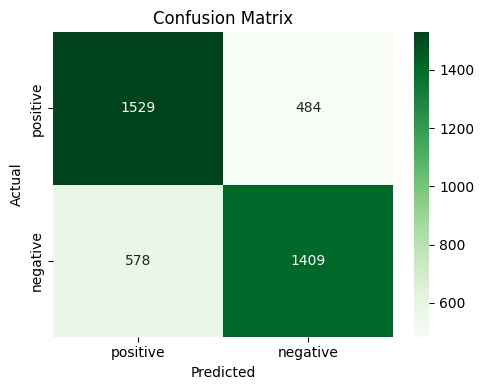

In [8]:
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))
print("Macro F1 Score:", round(f1_score(y_test, y_pred, average='macro'), 3))

cm = confusion_matrix(y_test, y_pred, labels=['positive','negative'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['positive','negative'],
            yticklabels=['positive','negative'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords